In [50]:
from bs4 import BeautifulSoup
import requests
import time
import datetime
import pandas as pd
import smtplib
import csv

In [62]:
all_books = []

for page in range(1, 51):

    print(f"Scraping Page {page}...")

    url = f"https://books.toscrape.com/catalogue/page-{page}.html"

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)

    soup = BeautifulSoup(response.content, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    #print(f"\nPage {page}")
    for book in books:
        
        title = book.h3.a["title"]
        print(title)

        price = book.find("p",class_="price_color").text.strip()[1:]
        print(price)
        availability = book.find("p",class_="instock availability").text.strip()
        print(availability)
        rating = book.find("p",class_="star-rating")["class"][1]
        print(rating)
        book_link = ("https://books.toscrape.com/catalogue/"+ book.h3.a["href"])
        print(book_link)
        
        all_books.append([title,price,availability,rating,book_link])
        
        file_path = "/Users/aishutheanalyst/Downloads/books_full_data.csv"
        
        with open(
            file_path,
            "w",
            newline="",
            encoding="utf-8"
        ) as f:
        
            writer = csv.writer(f)
        
            writer.writerow([
                "Title",
                "Price",
                "Availability",
                "Rating",
                "Book_link"
            ])
        
            writer.writerows(all_books)
        
        print("Data saved successfully!")
        print(file_path)
                


        

       

   

Scraping Page 1...
A Light in the Attic
51.77
In stock
Three
https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html
Data saved successfully!
/Users/aishutheanalyst/Downloads/books_full_data.csv
Tipping the Velvet
53.74
In stock
One
https://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html
Data saved successfully!
/Users/aishutheanalyst/Downloads/books_full_data.csv
Soumission
50.10
In stock
One
https://books.toscrape.com/catalogue/soumission_998/index.html
Data saved successfully!
/Users/aishutheanalyst/Downloads/books_full_data.csv
Sharp Objects
47.82
In stock
Four
https://books.toscrape.com/catalogue/sharp-objects_997/index.html
Data saved successfully!
/Users/aishutheanalyst/Downloads/books_full_data.csv
Sapiens: A Brief History of Humankind
54.23
In stock
Five
https://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html
Data saved successfully!
/Users/aishutheanalyst/Downloads/books_full_data.csv
The Requiem Red
22.65
In s

ConnectionError: HTTPSConnectionPool(host='books.toscrape.com', port=443): Read timed out.

In [ ]:
print(all_books[:5])
print(len(all_books))

In [ ]:
import pandas as pd
df=pd.read_csv("/Users/aishutheanalyst/Downloads/books_full_data.csv")
df.head(10)

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/Users/aishutheanalyst/Downloads/books_full_data.csv")
df.head(5)

,Title,Price,Availability,Rating,Book_link
0,A Light in the Attic,51.77,In stock,Three,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,53.74,In stock,One,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,50.10,In stock,One,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,47.82,In stock,Four,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five,https://books.toscrape.com/catalogue/sapiens-a...


In [3]:

# Convert price to float
df["Price"] = df["Price"].astype(float)


In [21]:

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].replace(rating_map)

print(df.head())
print(df["Rating"].unique())

                                   Title  Price Availability Rating  \
0                   A Light in the Attic  51.77     In stock      3   
1                     Tipping the Velvet  53.74     In stock      1   
2                             Soumission  50.10     In stock      1   
3                          Sharp Objects  47.82     In stock      4   
4  Sapiens: A Brief History of Humankind  54.23     In stock      5   

                                           Book_link  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.com/catalogue/sapiens-a...  
[3 1 4 5 2]


In [22]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         740 non-null    str    
 1   Price         740 non-null    float64
 2   Availability  740 non-null    str    
 3   Rating        740 non-null    object 
 4   Book_link     740 non-null    str    
dtypes: float64(1), object(1), str(3)
memory usage: 29.0+ KB
None


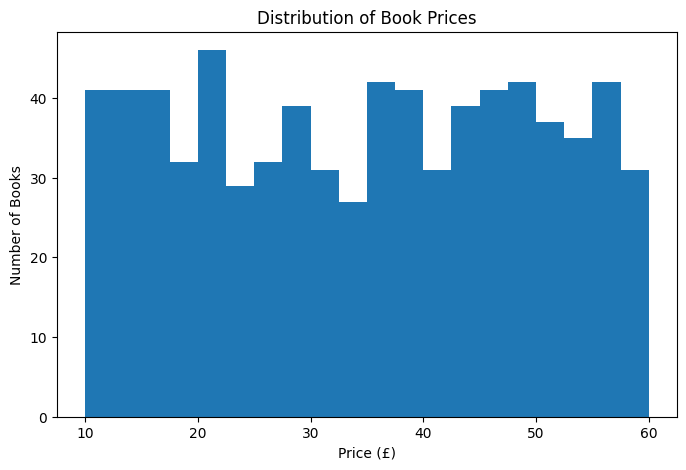

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=20)

plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")

plt.show()

In [31]:
print(df["Price"].describe())

count    740.000000
mean      34.868973
std       14.624599
min       10.000000
25%       21.532500
50%       35.835000
75%       47.625000
max       59.990000
Name: Price, dtype: float64


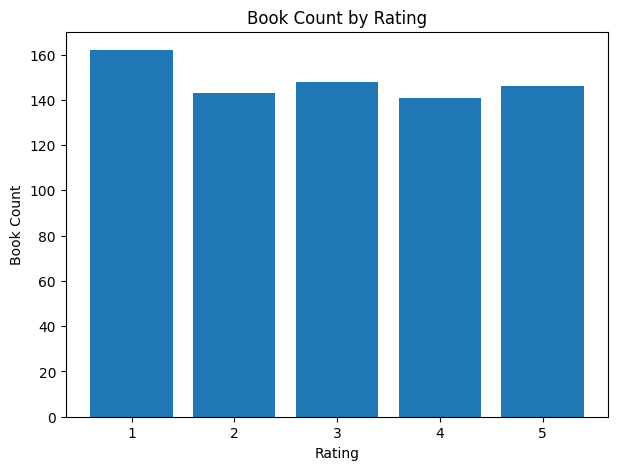

In [25]:
rating_count = (
    df["Rating"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7,5))

plt.bar(
    rating_count.index,
    rating_count.values
)

plt.xlabel("Rating")
plt.ylabel("Book Count")
plt.title("Book Count by Rating")

plt.show()

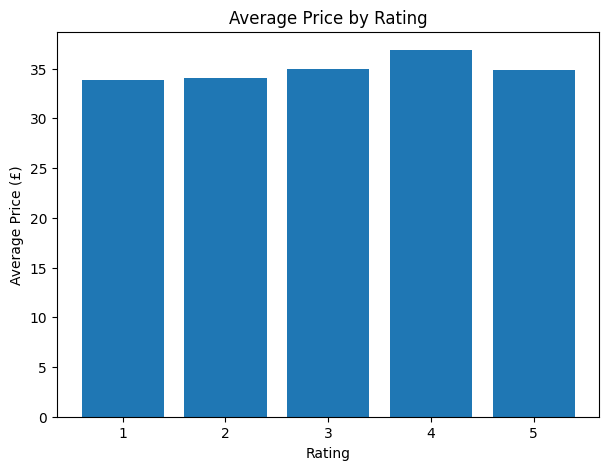

In [26]:
avg_price = (
    df.groupby("Rating")["Price"]
    .mean()
)

plt.figure(figsize=(7,5))

plt.bar(
    avg_price.index,
    avg_price.values
)

plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.title("Average Price by Rating")

plt.show()

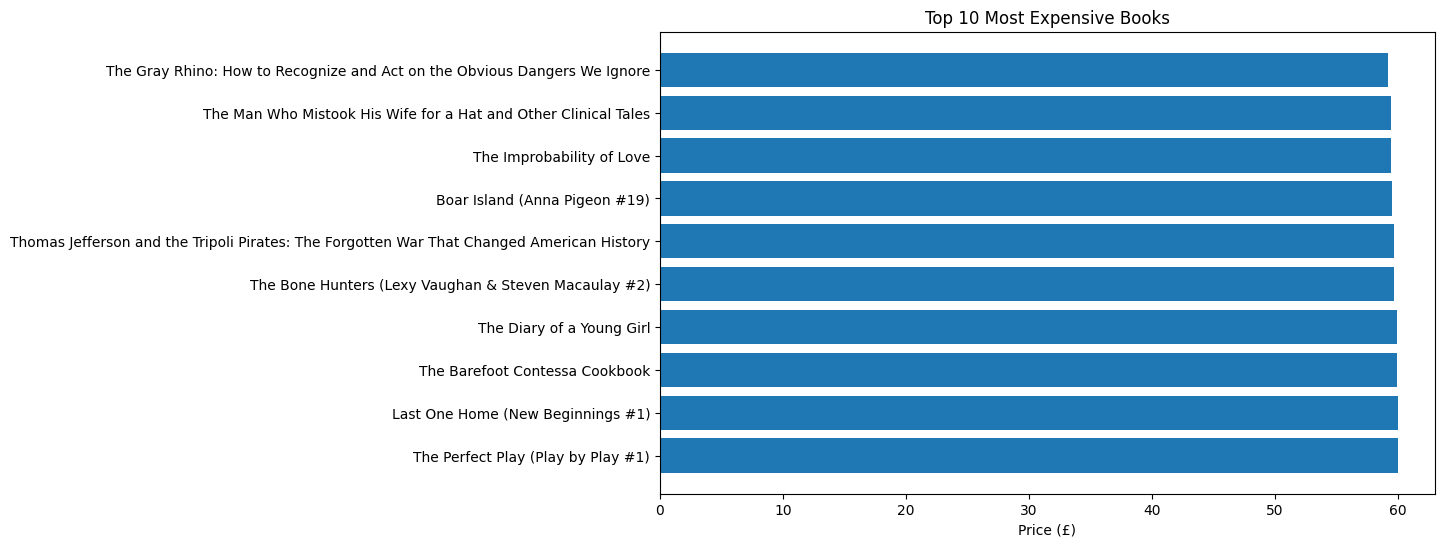

In [27]:
top_books = df.nlargest(10, "Price")

plt.figure(figsize=(10,6))

plt.barh(
    top_books["Title"],
    top_books["Price"]
)

plt.xlabel("Price (£)")
plt.title("Top 10 Most Expensive Books")

plt.show()

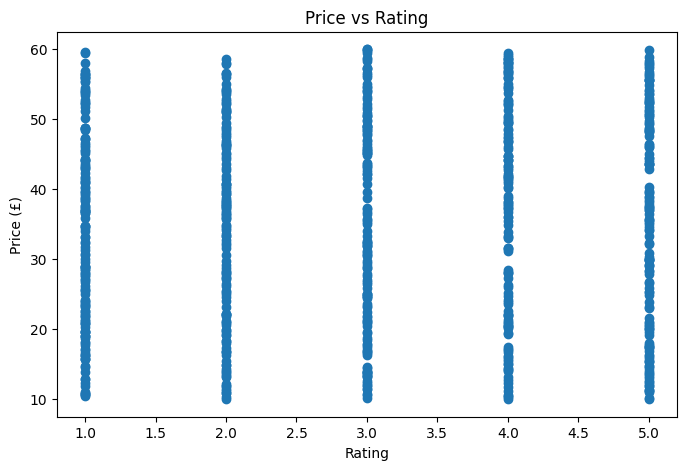

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Rating"],
    df["Price"]
)

plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.title("Price vs Rating")

plt.show()

In [30]:
# Cheapest books
cheapest_books = df.nsmallest(5,"Price")[["Title", "Price", "Book_link"]]

print("Cheapest Books")
print(cheapest_books)

print("\n")

# Most expensive books
expensive_books = df.nlargest(5,"Price")[["Title", "Price", "Book_link"]]

print("Most Expensive Books")
print(expensive_books)

Cheapest Books
                                                 Title  Price  \
638                         An Abundance of Katherines  10.00   
501                              The Origin of Species  10.01   
716  The Tipping Point: How Little Things Can Make ...  10.02   
84                                            Patience  10.16   
302                               Greek Mythic History  10.23   

                                             Book_link  
638  https://books.toscrape.com/catalogue/an-abunda...  
501  https://books.toscrape.com/catalogue/the-origi...  
716  https://books.toscrape.com/catalogue/the-tippi...  
84   https://books.toscrape.com/catalogue/patience_...  
302  https://books.toscrape.com/catalogue/greek-myt...  


Most Expensive Books
                                                 Title  Price  \
648                 The Perfect Play (Play by Play #1)  59.99   
617                  Last One Home (New Beginnings #1)  59.98   
560                     The Barefo

### Creating dummy price data

In [50]:
import pandas as pd
import random
from datetime import datetime, timedelta


# Read csv
books_df = pd.read_csv("/Users/aishutheanalyst/Downloads/books_full_data.csv")

#keep only needed columns
df =df[["Title","Price"]]

#create empty list to store historical records
price_history=[]

#number of historical days
days=7

#loop through each book
for _,row in df.iterrows():

    
    # Get book title
    title = row["Title"]


    #get current price
    base_price= float(row["Price"])

    # Set starting price
    current_price = base_price

    #create 7 days of history
    for i in range(days):

    #Generate date
    #today minus i days
        date=(datetime.today()-timedelta(days=i)).date()
        
    #create random price variation
   # Small gradual daily change
        price_change = random.uniform(
            -1.5,
            1.5
        )


    # Update previous day's price
        current_price = (
            current_price
            + price_change
        )


    # Round price
        new_price = round(
            current_price,
            2
        )


    # Prevent negative price
        new_price = max(
            new_price,
            5
        )


    # Save record
        price_history.append(
            [
                date,
                title,
                new_price
            ]
        )

    # Convert list to dataframe
history_df = pd.DataFrame(price_history,
    columns=[
        "Date",
        "Title",
        "Price"
       ]
 )

    # Save as CSV
history_df.to_csv("price_history.csv",index=False)


       
    # Print success message
print("Price history created!") 

          




Price history created!


In [49]:
history_df.head(20)

,Date,Title,Price
0,2026-06-08,A Light in the Attic,53.24
1,2026-06-07,A Light in the Attic,54.17
2,2026-06-06,A Light in the Attic,54.48
3,2026-06-05,A Light in the Attic,55.12
4,2026-06-04,A Light in the Attic,55.97
5,2026-06-03,A Light in the Attic,55.30
6,2026-06-02,A Light in the Attic,54.89
7,2026-06-08,Tipping the Velvet,53.49
8,2026-06-07,Tipping the Velvet,53.11
9,2026-06-06,Tipping the Velvet,52.11


## Compare current vs old price

In [51]:
import pandas as pd

# Current scraped data
books_df = pd.read_csv(
    "/Users/aishutheanalyst/Downloads/books_full_data.csv"
)

# Historical price data
history_df = pd.read_csv(
    "price_history.csv"
)

print(books_df.head())
print(history_df.head())

                                   Title  Price Availability Rating  \
0                   A Light in the Attic  51.77     In stock  Three   
1                     Tipping the Velvet  53.74     In stock    One   
2                             Soumission  50.10     In stock    One   
3                          Sharp Objects  47.82     In stock   Four   
4  Sapiens: A Brief History of Humankind  54.23     In stock   Five   

                                           Book_link  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.com/catalogue/sapiens-a...  
         Date                 Title  Price
0  2026-06-08  A Light in the Attic  50.36
1  2026-06-07  A Light in the Attic  51.47
2  2026-06-06  A Light in the Attic  52.80
3  2026-06-05  A Light in the Attic  52.93
4  2026-06-04  A Light in th

In [53]:
history_df["Date"] = pd.to_datetime(
    history_df["Date"]
)

latest_prices = (
    history_df
    .sort_values("Date")
    .groupby("Title")
    .tail(1)
)

print(latest_prices.head(8))

           Date                                              Title  Price
1554 2026-06-08  We Are Robin, Vol. 1: The Vigilante Business (...  54.93
1743 2026-06-08  The Help Yourself Cookbook for Kids: 60 Easy P...  29.16
1708 2026-06-08                                          The Loney  22.24
1659 2026-06-08                              The Songs of the Gods  43.12
1736 2026-06-08        The Hidden Oracle (The Trials of Apollo #1)  51.18
4823 2026-06-08      A New Earth: Awakening to Your Life's Purpose  56.74
4746 2026-06-08                          Girl With a Pearl Earring  26.81
1687 2026-06-08                          The Marriage of Opposites  29.50


In [54]:
comparison_df = books_df.merge(
    latest_prices[
        ["Title", "Price"]
    ],
    on="Title",
    suffixes=(
        "_current",
        "_old"
    )
)

print(comparison_df.head())

                                   Title  Price_current Availability Rating  \
0                   A Light in the Attic          51.77     In stock  Three   
1                     Tipping the Velvet          53.74     In stock    One   
2                             Soumission          50.10     In stock    One   
3                          Sharp Objects          47.82     In stock   Four   
4  Sapiens: A Brief History of Humankind          54.23     In stock   Five   

                                           Book_link  Price_old  
0  https://books.toscrape.com/catalogue/a-light-i...      50.36  
1  https://books.toscrape.com/catalogue/tipping-t...      52.49  
2  https://books.toscrape.com/catalogue/soumissio...      50.71  
3  https://books.toscrape.com/catalogue/sharp-obj...      46.33  
4  https://books.toscrape.com/catalogue/sapiens-a...      54.64  


In [55]:
comparison_df[
    "Price_Drop"
] = (
    comparison_df[
        "Price_current"
    ]
    <
    comparison_df[
        "Price_old"
    ]
)

print(
    comparison_df[
        [
            "Title",
            "Price_current",
            "Price_old",
            "Price_Drop"
        ]
    ]
)

                                     Title  Price_current  Price_old  \
0                     A Light in the Attic          51.77      50.36   
1                       Tipping the Velvet          53.74      52.49   
2                               Soumission          50.10      50.71   
3                            Sharp Objects          47.82      46.33   
4    Sapiens: A Brief History of Humankind          54.23      54.64   
..                                     ...            ...        ...   
735           The Nanny Diaries (Nanny #1)          52.53      51.94   
736               The Name of God is Mercy          37.25      38.08   
737   The Maze Runner (The Maze Runner #1)          20.93      19.51   
738                 The Lover's Dictionary          58.09      58.95   
739                        The Lonely Ones          43.59      44.81   

     Price_Drop  
0         False  
1         False  
2          True  
3         False  
4          True  
..          ...  
735      

## Price trend Analysis

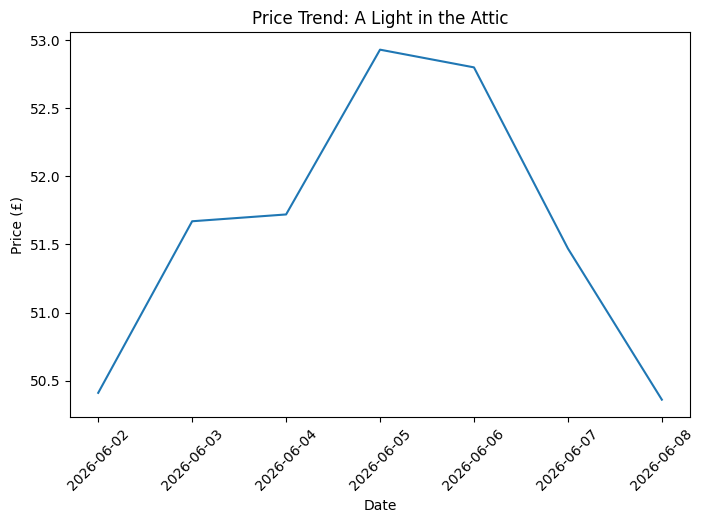

In [56]:
import matplotlib.pyplot as plt

book_name = (
    "A Light in the Attic"
)

book_history = history_df[
    history_df["Title"]
    == book_name
]

plt.figure(figsize=(8,5))

plt.plot(
    book_history["Date"],
    book_history["Price"]
)

plt.xlabel("Date")
plt.ylabel("Price (£)")
plt.title(
    f"Price Trend: {book_name}"
)

plt.xticks(rotation=45)

plt.show()

## Send Email

In [68]:
import pandas as pd
import smtplib
from email.message import EmailMessage

# -------------------------
# Load CSV files
# -------------------------

books_df = pd.read_csv(
    "/Users/aishutheanalyst/Downloads/books_full_data.csv"
)

history_df = pd.read_csv(
    "price_history.csv"
)

# -------------------------
# Convert date column
# -------------------------

history_df["Date"] = pd.to_datetime(
    history_df["Date"]
)

# -------------------------
# Get latest old price
# -------------------------

latest_prices = (
    history_df
    .sort_values("Date")
    .groupby("Title")
    .tail(1)
)

# -------------------------
# Merge current + old price
# -------------------------

comparison_df = books_df.merge(
    latest_prices[
        ["Title", "Price"]
    ],
    on="Title",
    suffixes=(
        "_current",
        "_old"
    )
)

# -------------------------
# Email credentials
# -------------------------

my_email = "aishuthedataanalyst@gmail.com"

app_password = "xflz hrpk dhos kfel"

# -------------------------
# Check price drops
# -------------------------

for _, row in comparison_df.iterrows():

    title = row["Title"]
    title = str(title).replace(
        "\xa0",
        " "
    )

    current_price = row[
        "Price_current"
    ]

    old_price = row[
        "Price_old"
    ]

    # Calculate percentage drop
    price_drop_percent = (
        (old_price - current_price)
        / old_price
    ) * 100

    # Alert only if drop >= 10%
    if price_drop_percent >= 10:

        # Create email
        msg = EmailMessage()

        msg["Subject"] = (
            "Book Price Alert!"
        )

        msg["From"] = my_email
        msg["To"] = my_email

        msg.set_content(
            f"Price dropped for:\n\n"
            f"{title}\n\n"
            f"Old Price: £"
            f"{old_price}\n"
            f"Current Price: £"
            f"{current_price}\n\n"
            f"Price Drop: "
            f"{price_drop_percent:.2f}%"
        )

        # Send email
        with smtplib.SMTP(
            "smtp.gmail.com",
            587
        ) as connection:

            connection.starttls()

            connection.login(
                user=my_email,
                password=app_password
            )

            connection.send_message(
                msg
            )

        print(
            f"Email sent for "
            f"{title}"
        )

print(
    "Price check completed!"
)

Email sent for Patience
Email sent for The Project
Email sent for The Lucifer Effect: Understanding How Good People Turn Evil
Email sent for Tastes Like Fear (DI Marnie Rome #3)


KeyboardInterrupt: 